# Beer Recommender — Phase 2: MF → GMF → MLP → NeuMF Pipeline

**Method:** He et al., *Neural Collaborative Filtering*, WWW 2017  
**Dataset:** BeerAdvocate + RateBeer (Stanford SNAP)  

Single end-to-end pipeline: data loading → preprocessing → MF baseline → NeuMF → evaluation → beer recommendations.

## Table of Contents
1. [Imports & Device](#1-imports--device)
2. [Data Loading (Google Drive)](#2-data-loading)
3. [Preprocessing & K-Core Filtering](#3-preprocessing)
4. [Chronological Train / Val / Test Split](#4-split)
5. [ID Mappings — train only, no leakage](#5-id-mappings)
6. [Dataset & DataLoaders](#6-dataloaders)
7. [MF Baseline](#7-mf-baseline)
8. [NeuMF — GMF Pre-training](#8-gmf)
9. [NeuMF — MLP Pre-training](#9-mlp)
10. [NeuMF — Fusion & Fine-tuning](#10-neumf)
11. [Rating-Prediction Results](#11-rating-results)
12. [Ranking Results (NDCG / Precision / Recall @K)](#12-ranking)
13. [Beer Recommendations](#13-recommendations)


## 1. Imports & Device


In [30]:
import os, ast, copy, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 60)

# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    torch.cuda.empty_cache()
    torch.cuda.manual_seed_all(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Device: Apple MPS')
else:
    DEVICE = torch.device('cpu')
    print('Device: CPU')
print('Active device:', DEVICE)


GPU: Tesla T4
Active device: cuda


## 2. Data Loading


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

BASE_PATH = Path('/content/drive/MyDrive/RCCSYS')
SOURCE_FILES = {
    'beeradvocate': BASE_PATH / 'beeradvocate.json',
    'ratebeer':     BASE_PATH / 'ratebeer.json',
}
for name, path in SOURCE_FILES.items():
    status = f'{path.stat().st_size/1e6:.0f} MB' if path.exists() else 'NOT FOUND'
    print(f'  {name:14s} -> {status}')


Mounted at /content/drive
  beeradvocate   -> 1655 MB
  ratebeer       -> 1930 MB


In [3]:
def load_dict_per_line(filepath):
    """Load a file where each line is a Python dict literal."""
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(ast.literal_eval(line))
    return pd.DataFrame(records)

t0 = time.time()
beer_advocate = load_dict_per_line(SOURCE_FILES['beeradvocate'])
rate_beer     = load_dict_per_line(SOURCE_FILES['ratebeer'])
print(f'Loaded in {time.time()-t0:.1f}s')
print('BeerAdvocate shape:', beer_advocate.shape)
print('RateBeer shape:    ', rate_beer.shape)


Loaded in 274.3s
BeerAdvocate shape: (1586615, 13)
RateBeer shape:     (2924164, 13)


## 3. Preprocessing & K-Core Filtering


In [4]:
def parse_rating(val):
    try:
        s = str(val)
        if '/' in s:
            num, denom = s.split('/')
            return float(num) / float(denom)
        return float(s)
    except (ValueError, TypeError):
        return np.nan

RATING_COLS = ['review/appearance', 'review/aroma', 'review/palate',
               'review/taste', 'review/overall']

# Parse & normalise ratings
for col in RATING_COLS:
    beer_advocate[col] = beer_advocate[col].apply(parse_rating)
    rate_beer[col]     = rate_beer[col].apply(parse_rating)
beer_advocate[RATING_COLS] = beer_advocate[RATING_COLS] / 5.0   # 0-5 → 0-1

# Parse timestamps (needed for chronological split)
for df_ in (beer_advocate, rate_beer):
    df_['beer/ABV']    = pd.to_numeric(df_['beer/ABV'], errors='coerce')
    df_['review/time'] = pd.to_numeric(df_['review/time'], errors='coerce')

# Source label + combine
beer_advocate['source'] = 'beeradvocate'
rate_beer['source']     = 'ratebeer'
df = pd.concat([beer_advocate, rate_beer], ignore_index=True)

# Globally unique item ID — prefix BEFORE any filtering
df['item_id'] = df['source'] + '_' + df['beer/beerId'].astype(str)

# Keep a name lookup for recommendations (before filtering)
item_name_lookup = (
    df.dropna(subset=['item_id', 'beer/name'])
    .drop_duplicates('item_id')[['item_id', 'beer/name', 'beer/style', 'beer/ABV', 'source']]
    .set_index('item_id')
)

# Drop rows missing core fields
before = len(df)
df = df.dropna(subset=['review/profileName', 'item_id', 'review/overall']).copy()
df = df.drop_duplicates(subset=['review/profileName', 'item_id'], keep='first').copy()
print(f'After null/dedup: {before:,} → {len(df):,}')

# K-core filtering: keep users AND items with >= 10 interactions
# Iterate 5 times so both sides stabilise together
MIN_REVIEWS = 10
for iteration in range(5):
    prev = len(df)
    uc = df['review/profileName'].value_counts()
    ic = df['item_id'].value_counts()
    df = df[df['review/profileName'].isin(uc[uc >= MIN_REVIEWS].index)]
    df = df[df['item_id'].isin(ic[ic >= MIN_REVIEWS].index)]
    print(f'  K-core iter {iteration+1}: {prev:,} → {len(df):,}')
    if len(df) == prev:
        break

df = df.reset_index(drop=True)
n_ratings = len(df)
n_raw_users = df['review/profileName'].nunique()
n_raw_items = df['item_id'].nunique()
sparsity = 1 - n_ratings / (n_raw_users * n_raw_items)

print(f'\nFinal dataset: {n_ratings:,} ratings | '
      f'{n_raw_users:,} users | {n_raw_items:,} items')
print(f'Sparsity: {sparsity:.4%}')
print(f'Mean rating (normalised): {df["review/overall"].mean():.4f}')


After null/dedup: 4,510,779 → 4,427,040
  K-core iter 1: 4,427,040 → 3,955,615
  K-core iter 2: 3,955,615 → 3,948,441
  K-core iter 3: 3,948,441 → 3,947,948
  K-core iter 4: 3,947,948 → 3,947,930
  K-core iter 5: 3,947,930 → 3,947,930

Final dataset: 3,947,930 ratings | 19,144 users | 48,104 items
Sparsity: 99.5713%
Mean rating (normalised): 0.6993


## 4. Chronological Train / Val / Test Split

For each user, sort by review time, then:
- Oldest 80% → **train**
- Next 10% → **val** (used only for early-stopping decisions)
- Last 10% → **test** (held out until final evaluation)

Users with < 10 reviews go entirely into train to avoid degenerate splits.
Val and test are filtered to only seen (train) users and items to prevent leakage.


In [5]:
# Sort each user's reviews chronologically
df_sorted = df.sort_values(['review/profileName', 'review/time']).reset_index(drop=True)

train_parts, val_parts, test_parts = [], [], []
MIN_INTERACTIONS = 10  # must match k-core threshold

for _, g in df_sorted.groupby('review/profileName', sort=False):
    n = len(g)
    if n < MIN_INTERACTIONS:
        train_parts.append(g)
        continue
    n_test  = max(1, int(round(0.1 * n)))
    n_val   = max(1, int(round(0.1 * n)))
    n_train = n - n_val - n_test
    if n_train < 1:
        train_parts.append(g)
        continue
    train_parts.append(g.iloc[:n_train])
    val_parts.append(g.iloc[n_train:n_train + n_val])
    test_parts.append(g.iloc[n_train + n_val:])

train_df = pd.concat(train_parts, ignore_index=True)
val_df   = pd.concat(val_parts,   ignore_index=True) if val_parts   else pd.DataFrame(columns=df.columns)
test_df  = pd.concat(test_parts,  ignore_index=True) if test_parts  else pd.DataFrame(columns=df.columns)

print(f'Train: {len(train_df):,}  ({100*len(train_df)/len(df):.1f}%)')
print(f'Val:   {len(val_df):,}  ({100*len(val_df)/len(df):.1f}%)')
print(f'Test:  {len(test_df):,}  ({100*len(test_df)/len(df):.1f}%)')


Train: 3,158,714  (80.0%)
Val:   394,608  (10.0%)
Test:  394,608  (10.0%)


## 5. ID Mappings — train only, no leakage

Mappings are built **only from the training set**. Val and test are then filtered
to users/items seen in train before indices are assigned. Any unseen user or item
in val/test is dropped — this is the correct cold-start protocol.


In [6]:
# Build integer index mappings FROM TRAIN ONLY
train_users = sorted(train_df['review/profileName'].unique())
train_items = sorted(train_df['item_id'].unique())

user2idx = {u: i for i, u in enumerate(train_users)}
item2idx = {it: i for i, it in enumerate(train_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

n_users = len(user2idx)
n_items = len(item2idx)

# Filter val/test: only rows whose user AND item appear in train
# This prevents any unseen-entity leakage into embeddings
val_df  = val_df[
    val_df['review/profileName'].isin(user2idx) &
    val_df['item_id'].isin(item2idx)
].copy()
test_df = test_df[
    test_df['review/profileName'].isin(user2idx) &
    test_df['item_id'].isin(item2idx)
].copy()

# Assign integer indices
for frame in (train_df, val_df, test_df):
    frame['user_idx'] = frame['review/profileName'].map(user2idx)
    frame['item_idx'] = frame['item_id'].map(item2idx)

global_mean = float(train_df['review/overall'].mean())

print(f'n_users : {n_users:,}')
print(f'n_items : {n_items:,}')
print(f'Train   : {len(train_df):,}  interactions')
print(f'Val     : {len(val_df):,}  interactions')
print(f'Test    : {len(test_df):,}  interactions')
print(f'Global mean rating: {global_mean:.4f}')

# Sanity check: no index out of range
assert train_df['user_idx'].max() < n_users
assert train_df['item_idx'].max() < n_items
assert val_df['user_idx'].max()   < n_users
assert test_df['item_idx'].max()  < n_items
print('Index range checks passed.')


n_users : 19,144
n_items : 47,795
Train   : 3,158,714  interactions
Val     : 393,912  interactions
Test    : 391,050  interactions
Global mean rating: 0.6970
Index range checks passed.


## 6. Dataset & DataLoaders


In [7]:
class RatingDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.users   = torch.tensor(frame['user_idx'].values, dtype=torch.long)
        self.items   = torch.tensor(frame['item_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(frame['review/overall'].values, dtype=torch.float32)
    def __len__(self):  return len(self.ratings)
    def __getitem__(self, idx): return self.users[idx], self.items[idx], self.ratings[idx]

BATCH    = 4096
N_WORK   = 2
PIN      = (DEVICE.type == 'cuda')

train_ds = RatingDataset(train_df)
val_ds   = RatingDataset(val_df)
test_ds  = RatingDataset(test_df)

train_loader = DataLoader(train_ds, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
val_loader   = DataLoader(val_ds,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
test_loader  = DataLoader(test_ds,  batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)

print(f'Train batches: {len(train_loader)}  |  Val: {len(val_loader)}  |  Test: {len(test_loader)}')


Train batches: 772  |  Val: 49  |  Test: 48


### Shared training utilities


In [8]:
criterion = nn.MSELoss()

# ── Evaluation helpers ────────────────────────────────────────────────────
@torch.no_grad()
def eval_rmse(loader, model):
    model.eval()
    se, n = 0.0, 0
    for u, i, r in loader:
        u, i, r = u.to(DEVICE, non_blocking=True), i.to(DEVICE, non_blocking=True), r.to(DEVICE, non_blocking=True)
        p = model(u, i)
        se += ((p - r) ** 2).sum().item(); n += len(r)
    return float(np.sqrt(se / n))

@torch.no_grad()
def eval_mae(loader, model):
    model.eval()
    ae, n = 0.0, 0
    for u, i, r in loader:
        u, i, r = u.to(DEVICE, non_blocking=True), i.to(DEVICE, non_blocking=True), r.to(DEVICE, non_blocking=True)
        p = model(u, i)
        ae += torch.abs(p - r).sum().item(); n += len(r)
    return float(ae / n)

# ── Generic training epoch (works for MF, GMF, MLP, NeuMF via l2_reg method) ─
def train_epoch(loader, model, optimizer, embed_reg=1e-5, bias_reg=5e-7, grad_clip=0.5):
    model.train()
    total_mse, total_n = 0.0, 0
    for u, i, r in loader:
        u, i, r = u.to(DEVICE, non_blocking=True), i.to(DEVICE, non_blocking=True), r.to(DEVICE, non_blocking=True)
        preds = model(u, i)
        loss  = criterion(preds, r) + model.l2_reg(u, i, embed_reg, bias_reg)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        # Track MSE without reg for accurate RMSE reporting
        with torch.no_grad():
            total_mse += criterion(preds, r).item() * len(r)
            total_n   += len(r)
    return float(np.sqrt(total_mse / total_n))

# ── Generic training loop with early stopping ─────────────────────────────
def run_training(model, tr_loader, vl_loader, cfg, label='Model'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=0.0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

    hist = {'epoch': [], 'train_rmse': [], 'val_rmse': [], 'val_mae': []}
    best_rmse, best_state, no_imp = float('inf'), None, 0

    print(f'\n--- Training {label} ---')
    for epoch in range(1, cfg['n_epochs'] + 1):
        tr = train_epoch(tr_loader, model, optimizer,
                         embed_reg=cfg.get('embed_reg', 1e-5),
                         bias_reg=cfg.get('bias_reg', 5e-7),
                         grad_clip=cfg.get('grad_clip', 0.5))
        vr = eval_rmse(vl_loader, model)
        vm = eval_mae(vl_loader,  model)
        scheduler.step(vr)

        hist['epoch'].append(epoch)
        hist['train_rmse'].append(tr)
        hist['val_rmse'].append(vr)
        hist['val_mae'].append(vm)

        improved = vr < best_rmse - cfg.get('min_delta', 1e-5)
        if improved:
            best_rmse  = vr
            best_state = copy.deepcopy(model.state_dict())
            no_imp = 0; flag = ' ✓'
        else:
            no_imp += 1; flag = ''

        if epoch % 5 == 0 or epoch == 1 or improved:
            print(f'  Epoch {epoch:>3} | train {tr:.4f} | val {vr:.4f} | mae {vm:.4f}{flag}')

        if no_imp >= cfg.get('patience', 5):
            print(f'  Early stop at epoch {epoch}. Best val RMSE={best_rmse:.4f}')
            break

    model.load_state_dict(best_state)
    print(f'  Done — best val RMSE: {best_rmse:.4f}')
    return hist, best_rmse

print('Utilities ready.')


Utilities ready.


## 7. Baselines

### 7a. Popularity baseline (Bayesian smoothing)


In [9]:
C = global_mean
m = 25  # smoothing count

item_stats = (
    train_df.groupby('item_id')['review/overall']
    .agg(count='count', mean='mean')
    .assign(score=lambda x: (x['count'] * x['mean'] + m * C) / (x['count'] + m))
    .sort_values('score', ascending=False)
)
item_score_lookup = item_stats['score'].to_dict()

print(f'Global mean: {C:.4f}')
print('Top-5 beers by Bayesian score:')
top5 = item_stats.head(5).join(item_name_lookup[['beer/name', 'beer/style']])
display(top5[['beer/name', 'beer/style', 'count', 'mean', 'score']].round(4))


Global mean: 0.6970
Top-5 beers by Bayesian score:


,beer/name,beer/style,count,mean,score
item_id,,,,,
beeradvocate_1545,Trappist Westvleteren 12,Quadrupel (Quad),936,0.9218,0.9159
beeradvocate_7971,Pliny The Elder,American Double / Imperial IPA,1761,0.9183,0.9152
ratebeer_4934,Westvleteren 12,Abt/Quadrupel,1593,0.9094,0.9061
beeradvocate_21690,Pliny The Younger,American Double / Imperial IPA,417,0.9173,0.9048
beeradvocate_731,Weihenstephaner Hefeweissbier,Hefeweizen,1639,0.9008,0.8977


### 7b. User+Item Bias baseline


In [10]:
# These dicts are keyed on string user/item names — no index leakage
user_bias_lookup = (train_df.groupby('review/profileName')['review/overall'].mean() - global_mean).to_dict()
item_bias_lookup = (train_df.groupby('item_id')['review/overall'].mean()             - global_mean).to_dict()

@torch.no_grad()
def bias_pred_batch(df_eval):
    """Vectorised user+item bias prediction — no Python loop."""
    ub = df_eval['review/profileName'].map(user_bias_lookup).fillna(0.0).values
    ib = df_eval['item_id'].map(item_bias_lookup).fillna(0.0).values
    return np.clip(global_mean + ub + ib, 0.0, 1.0)

print('User+Item Bias baseline defined.')


User+Item Bias baseline defined.


## 7c. Matrix Factorization (Biased MF)


In [11]:
class MatrixFactorization(nn.Module):
    """Biased MF: r_hat = mu + b_u + b_i + U[u]·V[i]"""
    def __init__(self, n_users, n_items, n_factors=32, global_mean=0.5, dropout=0.3):
        super().__init__()
        self.user_factors = nn.Embedding(n_users, n_factors)
        self.item_factors = nn.Embedding(n_items, n_factors)
        self.user_bias    = nn.Embedding(n_users, 1)
        self.item_bias    = nn.Embedding(n_items, 1)
        self.dropout      = nn.Dropout(dropout)
        self.global_mean  = nn.Parameter(torch.tensor([global_mean], dtype=torch.float32),
                                         requires_grad=False)
        nn.init.normal_(self.user_factors.weight, std=0.01)
        nn.init.normal_(self.item_factors.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        u   = self.dropout(self.user_factors(users))
        v   = self.dropout(self.item_factors(items))
        dot = (u * v).sum(dim=1)
        ub  = self.user_bias(users).squeeze(-1)
        ib  = self.item_bias(items).squeeze(-1)
        return torch.clamp(self.global_mean + dot + ub + ib, 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf = self.user_factors(users); it = self.item_factors(items)
        ub = self.user_bias(users);    ib = self.item_bias(items)
        r  = embed_reg * (uf.pow(2).sum() + it.pow(2).sum()) / len(users)
        return r + bias_reg * (ub.pow(2).sum() + ib.pow(2).sum()) / len(users)


MF_CONFIG = {
    'n_factors': 32, 'lr': 5e-4, 'embed_reg': 1e-5, 'bias_reg': 5e-7,
    'dropout': 0.3,  'n_epochs': 30, 'patience': 5, 'min_delta': 1e-5,
    'grad_clip': 0.5,
}

mf_model = MatrixFactorization(
    n_users=n_users, n_items=n_items,
    n_factors=MF_CONFIG['n_factors'],
    global_mean=global_mean,
    dropout=MF_CONFIG['dropout'],
).to(DEVICE)
print(f'MF parameters: {sum(p.numel() for p in mf_model.parameters()):,}')


MF parameters: 2,208,988


In [12]:
mf_history, mf_best_val = run_training(
    mf_model, train_loader, val_loader, MF_CONFIG, label='MF')

# Measure on test — evaluate on BEST checkpoint (already loaded back)
mf_test_rmse = eval_rmse(test_loader, mf_model)
mf_test_mae  = eval_mae(test_loader,  mf_model)
mf_train_rmse = eval_rmse(train_loader, mf_model)
print(f'\nMF  train RMSE: {mf_train_rmse:.4f}')
print(f'MF  val   RMSE: {mf_best_val:.4f}')
print(f'MF  test  RMSE: {mf_test_rmse:.4f}  MAE: {mf_test_mae:.4f}')
gap = mf_train_rmse - mf_test_rmse
print(f'Train-Test gap: {gap:+.4f}  (positive = slight overfit, negative = underfit)')
if torch.cuda.is_available(): torch.cuda.empty_cache()



--- Training MF ---
  Epoch   1 | train 0.1357 | val 0.1136 | mae 0.0831 ✓
  Epoch   2 | train 0.1130 | val 0.1080 | mae 0.0788 ✓
  Epoch   3 | train 0.1084 | val 0.1067 | mae 0.0778 ✓
  Epoch   4 | train 0.1060 | val 0.1063 | mae 0.0774 ✓
  Epoch   5 | train 0.1042 | val 0.1062 | mae 0.0773 ✓
  Epoch  10 | train 0.0979 | val 0.1067 | mae 0.0776
  Early stop at epoch 10. Best val RMSE=0.1062
  Done — best val RMSE: 0.1062

MF  train RMSE: 0.0997
MF  val   RMSE: 0.1062
MF  test  RMSE: 0.1084  MAE: 0.0789
Train-Test gap: -0.0087  (positive = slight overfit, negative = underfit)


## 8. NeuMF — GMF Pre-training

Generalised Matrix Factorisation (GMF) is the linear tower of NeuMF.
It replaces the scalar dot product with an element-wise product $\mathbf{u} \odot \mathbf{v}$
passed through a single linear layer, making it composable with the MLP output.

GMF embeddings are **warm-started from the trained MF** so this stage converges quickly.


In [13]:
class GMF(nn.Module):
    """Generalised MF tower. Produces element-wise product u⊙v for NeuMF fusion."""
    def __init__(self, n_users, n_items, n_factors, global_mean=0.5, dropout=0.1):
        super().__init__()
        self.user_emb  = nn.Embedding(n_users, n_factors)
        self.item_emb  = nn.Embedding(n_items, n_factors)
        self.user_bias = nn.Embedding(n_users, 1)
        self.item_bias = nn.Embedding(n_items, 1)
        self.fc        = nn.Linear(n_factors, 1, bias=False)
        self.dropout   = nn.Dropout(dropout)
        self.mu        = nn.Parameter(torch.tensor(global_mean), requires_grad=False)
        nn.init.normal_(self.user_emb.weight,  std=0.01)
        nn.init.normal_(self.item_emb.weight,  std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)
        nn.init.ones_(self.fc.weight)   # uniform average initialisation

    def element_product(self, users, items):
        """Returns u⊙v (no activation) — used by NeuMF fusion."""
        return self.dropout(self.user_emb(users)) * self.dropout(self.item_emb(items))

    def forward(self, users, items):
        phi = self.element_product(users, items)          # [B, K]
        b_u = self.user_bias(users).squeeze(-1)           # [B]
        b_i = self.item_bias(items).squeeze(-1)           # [B]
        return torch.clamp(self.mu + self.fc(phi).squeeze(-1) + b_u + b_i, 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf = self.user_emb(users);   it = self.item_emb(items)
        ub = self.user_bias(users);  ib = self.item_bias(items)
        r  = embed_reg * (uf.pow(2).sum() + it.pow(2).sum()) / len(users)
        return r + bias_reg * (ub.pow(2).sum() + ib.pow(2).sum()) / len(users)


GMF_CONFIG = {
    'n_factors': 32, 'lr': 5e-4, 'embed_reg': 1e-5, 'bias_reg': 5e-7,
    'dropout': 0.1,  'n_epochs': 20, 'patience': 5, 'min_delta': 1e-5, 'grad_clip': 0.5,
}

gmf_model = GMF(n_users=n_users, n_items=n_items,
                n_factors=GMF_CONFIG['n_factors'],
                global_mean=global_mean,
                dropout=GMF_CONFIG['dropout']).to(DEVICE)

# Warm-start from trained MF weights
with torch.no_grad():
    gmf_model.user_emb.weight.copy_(mf_model.user_factors.weight)
    gmf_model.item_emb.weight.copy_(mf_model.item_factors.weight)
    gmf_model.user_bias.weight.copy_(mf_model.user_bias.weight)
    gmf_model.item_bias.weight.copy_(mf_model.item_bias.weight)
print(f'GMF parameters: {sum(p.numel() for p in gmf_model.parameters()):,}')
print('GMF warm-started from MF weights.')


GMF parameters: 2,209,020
GMF warm-started from MF weights.


In [14]:
gmf_loader_tr = DataLoader(train_ds, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
gmf_loader_vl = DataLoader(val_ds,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)

gmf_history, gmf_best_val = run_training(
    gmf_model, gmf_loader_tr, gmf_loader_vl, GMF_CONFIG, label='GMF')

gmf_state = copy.deepcopy(gmf_model.state_dict())  # save for NeuMF init
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'GMF pre-training done. Best val RMSE={gmf_best_val:.4f}')



--- Training GMF ---
  Epoch   1 | train 0.1004 | val 0.1072 | mae 0.0781 ✓
  Epoch   5 | train 0.0887 | val 0.1117 | mae 0.0817
  Early stop at epoch 6. Best val RMSE=0.1072
  Done — best val RMSE: 0.1072
GMF pre-training done. Best val RMSE=0.1072


## 9. NeuMF — MLP Pre-training

The MLP tower has its **own, separate** embedding tables (`U_mlp`, `V_mlp`).
It concatenates them and passes through stacked `Linear → BatchNorm → ReLU → Dropout`
blocks, halving the dimension at each step: $64 \to 32 \to 16 \to 8$.


In [15]:
class MLP(nn.Module):
    """MLP tower. Outputs a hidden vector for NeuMF fusion."""
    def __init__(self, n_users, n_items, n_factors, hidden_sizes=None, dropout=0.3):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [n_factors*2, n_factors, n_factors//2, n_factors//4]
        self.user_emb = nn.Embedding(n_users, n_factors)
        self.item_emb = nn.Embedding(n_items, n_factors)
        self.out_dim  = hidden_sizes[-1]
        layers, in_d  = [], n_factors * 2
        for h in hidden_sizes:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        self.mlp = nn.Sequential(*layers)
        self.fc  = nn.Linear(hidden_sizes[-1], 1)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def hidden(self, users, items):
        """Last hidden vector — fed into NeuMF fusion."""
        return self.mlp(torch.cat([self.user_emb(users), self.item_emb(items)], dim=1))

    def forward(self, users, items):
        return torch.clamp(torch.sigmoid(self.fc(self.hidden(users, items)).squeeze(-1)), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        uf = self.user_emb(users); it = self.item_emb(items)
        return embed_reg * (uf.pow(2).sum() + it.pow(2).sum()) / len(users)


MLP_CONFIG = {
    'n_factors': 32, 'hidden_sizes': [64, 32, 16, 8],
    'lr': 1e-3, 'embed_reg': 1e-5, 'bias_reg': 0.0,
    'dropout': 0.3, 'n_epochs': 25, 'patience': 5, 'min_delta': 1e-5, 'grad_clip': 0.5,
}

mlp_model = MLP(n_users=n_users, n_items=n_items,
                n_factors=MLP_CONFIG['n_factors'],
                hidden_sizes=MLP_CONFIG['hidden_sizes'],
                dropout=MLP_CONFIG['dropout']).to(DEVICE)
print(f'MLP parameters: {sum(p.numel() for p in mlp_model.parameters()):,}')
print(f'MLP output dim: {mlp_model.out_dim} → fed into NeuMF fusion layer')


MLP parameters: 2,149,201
MLP output dim: 8 → fed into NeuMF fusion layer


In [16]:
mlp_loader_tr = DataLoader(train_ds, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
mlp_loader_vl = DataLoader(val_ds,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)

mlp_history, mlp_best_val = run_training(
    mlp_model, mlp_loader_tr, mlp_loader_vl, MLP_CONFIG, label='MLP')

mlp_state = copy.deepcopy(mlp_model.state_dict())  # save for NeuMF init
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'MLP pre-training done. Best val RMSE={mlp_best_val:.4f}')



--- Training MLP ---
  Epoch   1 | train 0.1783 | val 0.1135 | mae 0.0841 ✓
  Epoch   2 | train 0.1287 | val 0.1085 | mae 0.0795 ✓
  Epoch   3 | train 0.1220 | val 0.1077 | mae 0.0787 ✓
  Epoch   4 | train 0.1195 | val 0.1075 | mae 0.0783 ✓
  Epoch   5 | train 0.1179 | val 0.1074 | mae 0.0782 ✓
  Epoch  10 | train 0.1130 | val 0.1076 | mae 0.0780
  Early stop at epoch 10. Best val RMSE=0.1074
  Done — best val RMSE: 0.1074
MLP pre-training done. Best val RMSE=0.1074


## 10. NeuMF — Fusion & Fine-tuning

NeuMF fuses both towers:
$$\hat{r} = \sigma\!\left(\mathbf{h}^\top \begin{bmatrix} \mathbf{u}^{\text{gmf}} \odot \mathbf{v}^{\text{gmf}} \\ \text{MLP}(\mathbf{u}^{\text{mlp}} \| \mathbf{v}^{\text{mlp}}) \end{bmatrix}\right)$$

**Initialisation (He et al. §3.4):**  
GMF branch ← pre-trained GMF weights  
MLP branch ← pre-trained MLP weights  
Fusion ← $[0.5 \times \mathbf{h}_{\text{gmf}},\; 0.5 \times \mathbf{h}_{\text{mlp}}]$  

Fine-tuning LR is 0.1× individual rates to preserve learned representations.


In [17]:
class NeuMF(nn.Module):
    """Neural MF (He et al. 2017) — GMF tower + MLP tower → fusion → prediction."""
    def __init__(self, n_users, n_items, gmf_factors=32, mlp_factors=32,
                 hidden_sizes=None, dropout_gmf=0.1, dropout_mlp=0.3):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [mlp_factors*2, mlp_factors, mlp_factors//2, mlp_factors//4]

        # GMF branch
        self.gmf_user = nn.Embedding(n_users, gmf_factors)
        self.gmf_item = nn.Embedding(n_items, gmf_factors)
        self.drop_gmf = nn.Dropout(dropout_gmf)

        # MLP branch
        self.mlp_user = nn.Embedding(n_users, mlp_factors)
        self.mlp_item = nn.Embedding(n_items, mlp_factors)
        layers, in_d  = [], mlp_factors * 2
        for h in hidden_sizes:
            layers += [nn.Linear(in_d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout_mlp)]
            in_d = h
        self.mlp     = nn.Sequential(*layers)
        self.mlp_out = hidden_sizes[-1]

        # Fusion: concat(GMF_out [K], MLP_out [mlp_out]) → scalar
        self.fusion = nn.Linear(gmf_factors + self.mlp_out, 1, bias=False)

        # Default inits
        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
        nn.init.constant_(self.fusion.weight, 0.5)

    def forward(self, users, items):
        u_g = self.drop_gmf(self.gmf_user(users))
        v_g = self.drop_gmf(self.gmf_item(items))
        gmf_out = u_g * v_g                                       # [B, K_gmf]
        mlp_out = self.mlp(torch.cat(
            [self.mlp_user(users), self.mlp_item(items)], dim=1)) # [B, mlp_out]
        logit = self.fusion(torch.cat([gmf_out, mlp_out], dim=1)).squeeze(-1)
        return torch.clamp(torch.sigmoid(logit), 0.0, 1.0)

    def l2_reg(self, users, items, embed_reg=1e-5, bias_reg=5e-7):
        embs = [self.gmf_user(users), self.gmf_item(items),
                self.mlp_user(users), self.mlp_item(items)]
        return embed_reg * sum(e.pow(2).sum() for e in embs) / len(users)


NEUMF_CONFIG = {
    'gmf_factors': 32, 'mlp_factors': 32,
    'hidden_sizes': [64, 32, 16, 8],
    'dropout_gmf': 0.1, 'dropout_mlp': 0.3,
    'lr': 5e-5,        # 0.1× individual LRs — fine-tune, not overwrite
    'embed_reg': 1e-5, 'bias_reg': 0.0,
    'n_epochs': 30, 'patience': 7, 'min_delta': 1e-5, 'grad_clip': 0.5,
}

neumf_model = NeuMF(
    n_users=n_users, n_items=n_items,
    gmf_factors=NEUMF_CONFIG['gmf_factors'],
    mlp_factors=NEUMF_CONFIG['mlp_factors'],
    hidden_sizes=NEUMF_CONFIG['hidden_sizes'],
    dropout_gmf=NEUMF_CONFIG['dropout_gmf'],
    dropout_mlp=NEUMF_CONFIG['dropout_mlp'],
).to(DEVICE)
print(f'NeuMF parameters: {sum(p.numel() for p in neumf_model.parameters()):,}')


NeuMF parameters: 4,291,280


In [18]:
# ── Initialise NeuMF from pre-trained towers (He et al. §3.4) ────────────
with torch.no_grad():
    # GMF embeddings
    neumf_model.gmf_user.weight.copy_(gmf_state['user_emb.weight'])
    neumf_model.gmf_item.weight.copy_(gmf_state['item_emb.weight'])

    # MLP embeddings
    neumf_model.mlp_user.weight.copy_(mlp_state['user_emb.weight'])
    neumf_model.mlp_item.weight.copy_(mlp_state['item_emb.weight'])

    # MLP internal layers (Linear + BN) — copy by matching state_dict keys
    neumf_sd  = neumf_model.state_dict()
    mismatches = []
    for k, v in mlp_state.items():
        if k.startswith('mlp.') and k in neumf_sd and neumf_sd[k].shape == v.shape:
            neumf_sd[k].copy_(v)
        elif k.startswith('mlp.'):
            mismatches.append(k)
    if mismatches:
        print(f'MLP keys skipped (shape mismatch): {mismatches}')

    # Fusion layer — equal half-weight from each tower's output projection
    gmf_fc = gmf_state['fc.weight']   # [1, K_gmf]
    mlp_fc = mlp_state['fc.weight']   # [1, mlp_out]
    neumf_model.fusion.weight.copy_(
        torch.cat([gmf_fc * 0.5, mlp_fc * 0.5], dim=1))

print('NeuMF initialised from pre-trained GMF + MLP weights.')
print(f'  GMF: {NEUMF_CONFIG["gmf_factors"]}D  |  '
      f'MLP: {NEUMF_CONFIG["mlp_factors"]}D → {NEUMF_CONFIG["hidden_sizes"]}  |  '
      f'Fusion: Linear({NEUMF_CONFIG["gmf_factors"] + neumf_model.mlp_out}, 1)')


NeuMF initialised from pre-trained GMF + MLP weights.
  GMF: 32D  |  MLP: 32D → [64, 32, 16, 8]  |  Fusion: Linear(40, 1)


In [19]:
neumf_loader_tr = DataLoader(train_ds, batch_size=BATCH,   shuffle=True,  num_workers=N_WORK, pin_memory=PIN)
neumf_loader_vl = DataLoader(val_ds,   batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)
neumf_loader_te = DataLoader(test_ds,  batch_size=BATCH*2, shuffle=False, num_workers=N_WORK, pin_memory=PIN)

neumf_history, neumf_best_val = run_training(
    neumf_model, neumf_loader_tr, neumf_loader_vl, NEUMF_CONFIG, label='NeuMF')

neumf_test_rmse = eval_rmse(neumf_loader_te, neumf_model)
neumf_test_mae  = eval_mae(neumf_loader_te,  neumf_model)
if torch.cuda.is_available(): torch.cuda.empty_cache()
print(f'NeuMF test RMSE: {neumf_test_rmse:.4f}  MAE: {neumf_test_mae:.4f}')



--- Training NeuMF ---
  Epoch   1 | train 0.1741 | val 0.1519 | mae 0.1293 ✓
  Epoch   2 | train 0.1499 | val 0.1325 | mae 0.1066 ✓
  Epoch   3 | train 0.1373 | val 0.1221 | mae 0.0950 ✓
  Epoch   4 | train 0.1289 | val 0.1160 | mae 0.0881 ✓
  Epoch   5 | train 0.1240 | val 0.1129 | mae 0.0846 ✓
  Epoch   6 | train 0.1209 | val 0.1108 | mae 0.0822 ✓
  Epoch   7 | train 0.1187 | val 0.1093 | mae 0.0808 ✓
  Epoch   8 | train 0.1171 | val 0.1087 | mae 0.0801 ✓
  Epoch   9 | train 0.1160 | val 0.1082 | mae 0.0795 ✓
  Epoch  10 | train 0.1149 | val 0.1078 | mae 0.0791 ✓
  Epoch  11 | train 0.1140 | val 0.1077 | mae 0.0791 ✓
  Epoch  12 | train 0.1133 | val 0.1076 | mae 0.0790 ✓
  Epoch  13 | train 0.1126 | val 0.1075 | mae 0.0787 ✓
  Epoch  14 | train 0.1119 | val 0.1074 | mae 0.0788 ✓
  Epoch  15 | train 0.1113 | val 0.1076 | mae 0.0788
  Epoch  20 | train 0.1086 | val 0.1077 | mae 0.0790
  Early stop at epoch 21. Best val RMSE=0.1074
  Done — best val RMSE: 0.1074
NeuMF test RMSE: 0.110

## 11. Learning Curves & Rating-Prediction Results


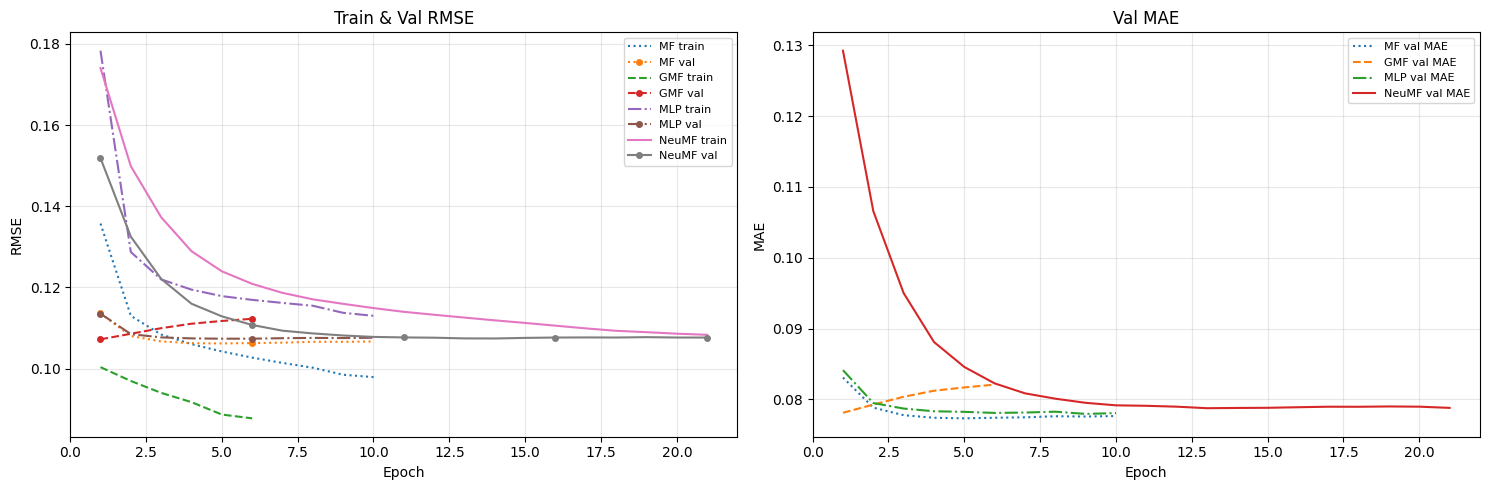

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for hist, lbl, ls in [
    (mf_history,    'MF',    ':'),
    (gmf_history,   'GMF',   '--'),
    (mlp_history,   'MLP',   '-.'),
    (neumf_history, 'NeuMF', '-'),
]:
    axes[0].plot(hist['epoch'], hist['train_rmse'], ls=ls, label=f'{lbl} train')
    axes[0].plot(hist['epoch'], hist['val_rmse'],   ls=ls, label=f'{lbl} val',
                 marker='o', markevery=5, markersize=4)
    axes[1].plot(hist['epoch'], hist['val_mae'], ls=ls, label=f'{lbl} val MAE')
for ax, ylabel, title in zip(axes, ['RMSE', 'MAE'],
                              ['Train & Val RMSE', 'Val MAE']):
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


        Rating-Prediction Results — Test Set


,RMSE,MAE
Model,,
Global Mean,0.1503,0.1140
Popularity (Bayesian),0.1184,0.0873
User+Item Bias,0.1278,0.0957
"MF (biased, K=32)",0.1084,0.0789
GMF (pre-train),0.1096,0.0798
MLP (pre-train),0.1093,0.0795
NeuMF (Phase 2),0.1100,0.0806



NeuMF vs MF: -1.47% RMSE improvement


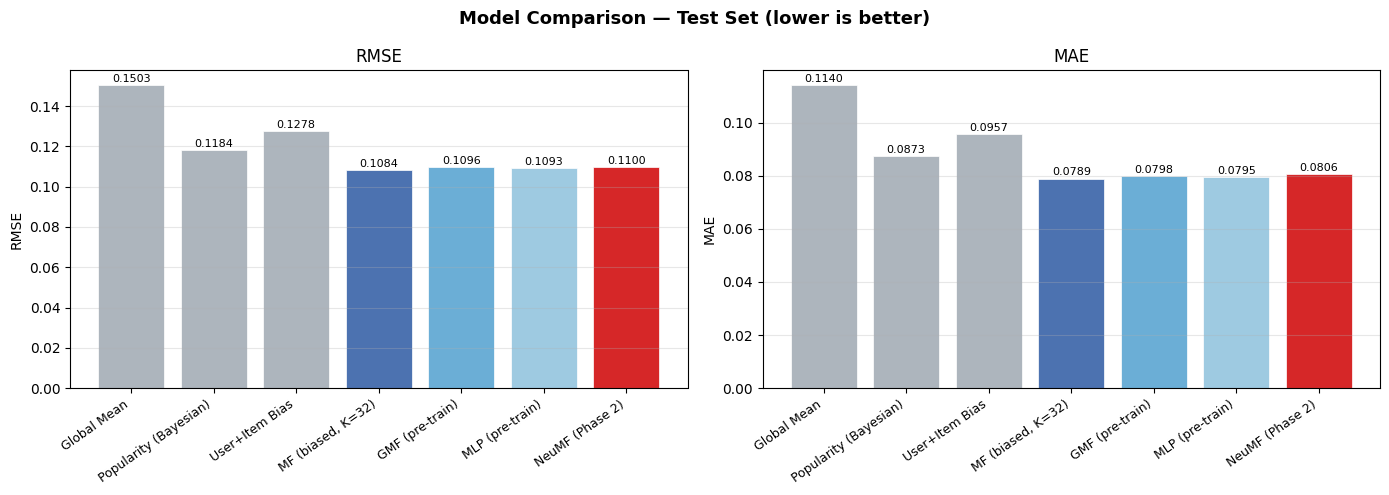

In [21]:
# ── Full rating-prediction comparison (test set) ──────────────────────────
test_truth      = test_df['review/overall'].values
pop_preds       = test_df['item_id'].map(item_score_lookup).fillna(C).values
bias_preds      = bias_pred_batch(test_df)

def arr_rmse(y_true, y_pred): return float(np.sqrt(np.mean((y_true - y_pred)**2)))
def arr_mae(y_true, y_pred):  return float(np.mean(np.abs(y_true - y_pred)))

results_rows = [
    {'Model': 'Global Mean',
     'RMSE': arr_rmse(test_truth, np.full_like(test_truth, global_mean)),
     'MAE':  arr_mae(test_truth,  np.full_like(test_truth, global_mean))},
    {'Model': 'Popularity (Bayesian)',
     'RMSE': arr_rmse(test_truth, pop_preds),
     'MAE':  arr_mae(test_truth,  pop_preds)},
    {'Model': 'User+Item Bias',
     'RMSE': arr_rmse(test_truth, bias_preds),
     'MAE':  arr_mae(test_truth,  bias_preds)},
    {'Model': 'MF (biased, K=32)',
     'RMSE': mf_test_rmse,
     'MAE':  mf_test_mae},
    {'Model': 'GMF (pre-train)',
     'RMSE': eval_rmse(neumf_loader_te, gmf_model),
     'MAE':  eval_mae(neumf_loader_te,  gmf_model)},
    {'Model': 'MLP (pre-train)',
     'RMSE': eval_rmse(neumf_loader_te, mlp_model),
     'MAE':  eval_mae(neumf_loader_te,  mlp_model)},
    {'Model': 'NeuMF (Phase 2)',
     'RMSE': neumf_test_rmse,
     'MAE':  neumf_test_mae},
]

results_df = pd.DataFrame(results_rows).set_index('Model')
print('='*55)
print('        Rating-Prediction Results — Test Set')
print('='*55)
display(results_df.round(4))

mf_r    = results_df.loc['MF (biased, K=32)',  'RMSE']
neu_r   = results_df.loc['NeuMF (Phase 2)',    'RMSE']
delta   = (mf_r - neu_r) / mf_r * 100
print(f'\nNeuMF vs MF: {delta:+.2f}% RMSE improvement')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#adb5bd','#adb5bd','#adb5bd','#4c72b0','#6baed6','#9ecae1','#d62728']
for ax, metric in zip(axes, ['RMSE', 'MAE']):
    vals = results_df[metric]
    bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel(metric); ax.set_title(metric); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Model Comparison — Test Set (lower is better)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Ranking Results (NDCG / Precision / Recall @K)

**Relevance:** rating ≥ 0.7 (≥ 3.5/5 on BeerAdvocate scale).  
**Candidate pool:** all items seen in train, excluding items already reviewed by that user.  
**Sampling:** 500 random test users for speed; same seed for MF and NeuMF comparison.


In [22]:
RELEVANCE_THRESHOLD = 0.7
K_LIST = [5, 10, 20]

def precision_at_k(recs, rel, k): return len(set(recs[:k]) & rel) / k if k else 0.0
def recall_at_k(recs, rel, k):    return len(set(recs[:k]) & rel) / len(rel) if rel else 0.0
def ndcg_at_k(recs, rel, k):
    dcg  = sum(1.0 / np.log2(r+2) for r, it in enumerate(recs[:k]) if it in rel)
    idcg = sum(1.0 / np.log2(r+2) for r in range(min(k, len(rel))))
    return dcg / idcg if idcg else 0.0

# Build lookup tables from TRAIN split only
train_seen = train_df.groupby('review/profileName')['item_id'].apply(set).to_dict()
test_rel   = (
    test_df[test_df['review/overall'] >= RELEVANCE_THRESHOLD]
    .groupby('review/profileName')['item_id'].apply(set).to_dict()
)
# Pre-build candidate arrays once — reused for every user and every model
all_items     = list(train_df['item_id'].unique())
all_item_idxs = np.array([item2idx[it] for it in all_items])

print(f'Candidate pool: {len(all_items):,} items')
print(f'Test users with >= 1 relevant item: {len(test_rel):,}')


Candidate pool: 47,795 items
Test users with >= 1 relevant item: 17,728


In [23]:
@torch.no_grad()
def gpu_score_user(model, u_idx, cand_idxs):
    """Score all candidates for one user in a single batched GPU forward pass."""
    model.eval()
    u = torch.full((len(cand_idxs),), u_idx, dtype=torch.long, device=DEVICE)
    v = torch.tensor(cand_idxs, dtype=torch.long, device=DEVICE)
    return model(u, v).cpu().numpy()


def ranking_eval(model, n_sample=500, seed=42):
    rng   = np.random.default_rng(seed)
    users = list(test_rel.keys())
    if len(users) > n_sample:
        users = list(rng.choice(users, n_sample, replace=False))
    per_k = {k: {'ndcg': [], 'prec': [], 'rec': []} for k in K_LIST}

    for user in users:
        u_idx = user2idx.get(user)
        if u_idx is None: continue
        seen  = train_seen.get(user, set())
        # Boolean mask: exclude items already seen in train
        mask  = np.array([it not in seen for it in all_items])
        cands = [it for it, m in zip(all_items, mask) if m]
        cidxs = all_item_idxs[mask]
        if not cands: continue

        scores = gpu_score_user(model, u_idx, cidxs)
        ranked = [it for _, it in sorted(zip(scores, cands), reverse=True)]
        rel    = test_rel[user]
        for k in K_LIST:
            per_k[k]['ndcg'].append(ndcg_at_k(ranked, rel, k))
            per_k[k]['prec'].append(precision_at_k(ranked, rel, k))
            per_k[k]['rec'].append(recall_at_k(ranked, rel, k))

    return {k: {m: float(np.mean(v)) for m, v in per_k[k].items()} for k in K_LIST}


print('Evaluating MF ranking ...')
mf_rank = ranking_eval(mf_model)
print('Evaluating NeuMF ranking ...')
neumf_rank = ranking_eval(neumf_model)

rank_rows = []
for k in K_LIST:
    for lbl, res in [('MF', mf_rank), ('NeuMF', neumf_rank)]:
        rank_rows.append({'Model': lbl, 'K': k,
                          'NDCG@K': res[k]['ndcg'],
                          'Prec@K': res[k]['prec'],
                          'Rec@K':  res[k]['rec']})
ranking_df = pd.DataFrame(rank_rows)
print('\n=== Ranking Metrics — Test Set ===')
display(ranking_df.round(4))


Evaluating MF ranking ...
Evaluating NeuMF ranking ...

=== Ranking Metrics — Test Set ===


,Model,K,NDCG@K,Prec@K,Rec@K
0,MF,5,0.0025,0.0032,0.0010
1,NeuMF,5,0.0028,0.0032,0.0019
2,MF,10,0.0041,0.0048,0.0027
3,NeuMF,10,0.0041,0.0040,0.0045
4,MF,20,0.0054,0.0044,0.0071
5,NeuMF,20,0.0046,0.0032,0.0068


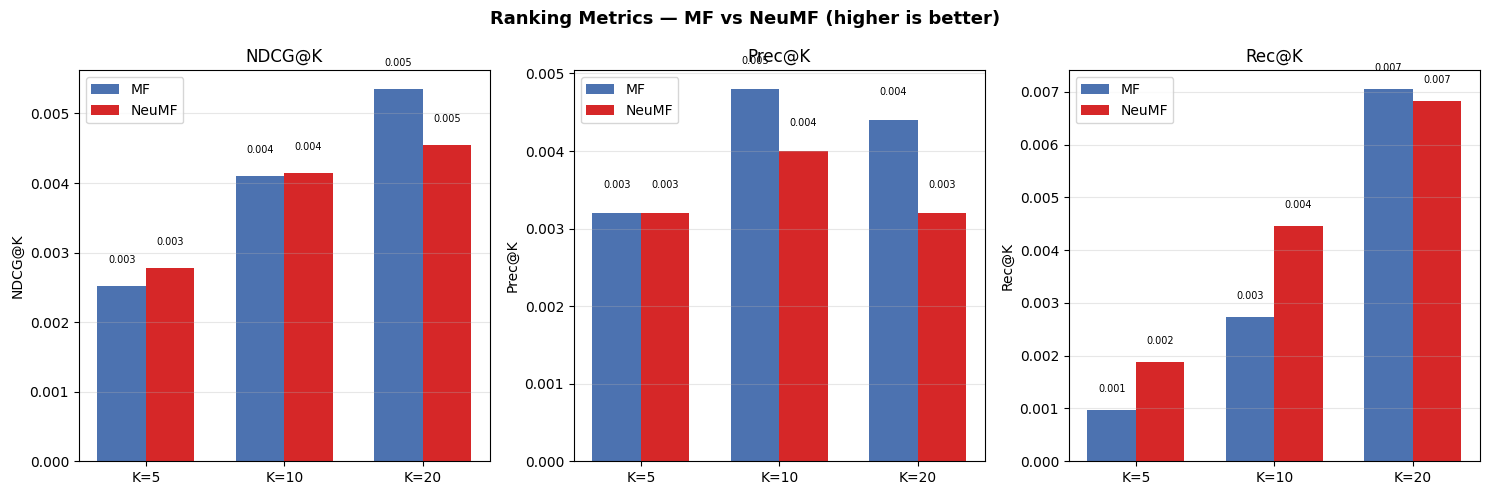

In [24]:
# Grouped bar chart for NDCG / Precision / Recall at each K
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bw = 0.35; x = np.arange(len(K_LIST))
metric_map = {'NDCG@K': 'ndcg', 'Prec@K': 'prec', 'Rec@K': 'rec'}

for ax, (metric, key) in zip(axes, metric_map.items()):
    mf_v    = [mf_rank[k][key]    for k in K_LIST]
    neu_v   = [neumf_rank[k][key] for k in K_LIST]
    b1 = ax.bar(x - bw/2, mf_v,  bw, label='MF',    color='#4c72b0')
    b2 = ax.bar(x + bw/2, neu_v, bw, label='NeuMF', color='#d62728')
    ax.set_xticks(x); ax.set_xticklabels([f'K={k}' for k in K_LIST])
    ax.set_title(metric); ax.set_ylabel(metric)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar, val in list(zip(b1, mf_v)) + list(zip(b2, neu_v)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Ranking Metrics — MF vs NeuMF (higher is better)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 13. Beer Recommendations

Given any username from the training set, each model scores all unseen items
and returns the top-K beers with their names, styles, and predicted ratings.


In [25]:
@torch.no_grad()
def recommend(model, username, top_k=10, model_name='Model'):
    """
    Return top-K beer recommendations for a given user.
    Only items NOT seen in training are candidates.

    Parameters
    ----------
    model    : trained PyTorch model (MF or NeuMF)
    username : str — review/profileName from the dataset
    top_k    : int — how many recommendations to return

    Returns
    -------
    pd.DataFrame with columns: Rank, Beer Name, Style, ABV, Pred Rating, Source
    """
    u_idx = user2idx.get(username)
    if u_idx is None:
        print(f'User "{username}" not found in training set.')
        return pd.DataFrame()

    seen  = train_seen.get(username, set())
    mask  = np.array([it not in seen for it in all_items])
    cands = [it for it, m in zip(all_items, mask) if m]
    cidxs = all_item_idxs[mask]

    # Single batched GPU forward pass for all candidates
    scores = gpu_score_user(model, u_idx, cidxs)

    # Sort descending and take top_k
    order   = np.argsort(-scores)
    top_ids = [cands[i] for i in order[:top_k]]
    top_scr = scores[order[:top_k]]

    rows = []
    for rank, (item_id, score) in enumerate(zip(top_ids, top_scr), 1):
        meta = item_name_lookup.loc[item_id] if item_id in item_name_lookup.index else {}
        rows.append({
            'Rank':        rank,
            'Beer Name':   meta.get('beer/name', item_id) if isinstance(meta, pd.Series) else item_id,
            'Style':       meta.get('beer/style', '-')   if isinstance(meta, pd.Series) else '-',
            'ABV':         meta.get('beer/ABV',   None)  if isinstance(meta, pd.Series) else None,
            f'Pred ({model_name})': round(float(score) * 5, 2),   # convert back to 0-5 scale
            'Source':      meta.get('source', '-')       if isinstance(meta, pd.Series) else '-',
        })

    return pd.DataFrame(rows).set_index('Rank')

print('recommend() function ready.')


recommend() function ready.


In [26]:
# ── Pick a user with a reasonably long history ────────────────────────────
# We pick a user who appears both in train (for the model) and test (for ground truth).
# Choosing a user with many train reviews gives more personalised recommendations.
user_review_counts = train_df['review/profileName'].value_counts()
example_user = user_review_counts.index[0]   # most active user in train

n_train_reviews = user_review_counts[example_user]
n_test_reviews  = len(test_df[test_df['review/profileName'] == example_user])
print(f'Example user: {example_user}')
print(f'  Train reviews : {n_train_reviews}')
print(f'  Test  reviews : {n_test_reviews}')

# Show what they've actually rated highly in the training set
user_train = train_df[train_df['review/profileName'] == example_user]
top_rated  = (
    user_train.nlargest(5, 'review/overall')
    [['item_id', 'review/overall']]
    .join(item_name_lookup[['beer/name', 'beer/style']], on='item_id')
)
top_rated['review/overall_5pt'] = (top_rated['review/overall'] * 5).round(2)
print(f'\nTop-5 beers rated by {example_user} in training set:')
display(top_rated[['beer/name', 'beer/style', 'review/overall_5pt']].reset_index(drop=True))


Example user: Ungstrup
  Train reviews : 10289
  Test  reviews : 1236

Top-5 beers rated by Ungstrup in training set:


,beer/name,beer/style,review/overall_5pt
0,Anchor Old Foghorn Ale,Barley Wine,4.75
1,Grottenbier Bruin,Abbey Dubbel,4.75
2,Boelens Waase Wolf,Belgian Ale,4.75
3,Brooklyn Monster Ale,Barley Wine,4.75
4,Schloss Eggenberg Samichlaus Bier,Doppelbock,4.75


In [27]:
TOP_K = 10

print(f'\n{'='*60}')
print(f'MF Recommendations for: {example_user}')
print(f'{'='*60}')
mf_recs = recommend(mf_model, example_user, top_k=TOP_K, model_name='MF')
display(mf_recs)

print(f'\n{'='*60}')
print(f'NeuMF Recommendations for: {example_user}')
print(f'{'='*60}')
neumf_recs = recommend(neumf_model, example_user, top_k=TOP_K, model_name='NeuMF')
display(neumf_recs)



MF Recommendations for: Ungstrup


,Beer Name,Style,ABV,Pred (MF),Source
Rank,,,,,
1,Veritas 004,American Wild Ale,8.0,4.37,beeradvocate
2,AleSmith Kopi Luwak Speedway Stout,Imperial Stout,12.2,4.35,ratebeer
3,Cigar City Hunahpus Imperial Stout - Brandy Ba...,Imperial Stout,11.0,4.34,ratebeer
4,Three Floyds Vanilla Bean Barrel Aged Dark Lor...,Imperial Stout,14.0,4.34,ratebeer
5,Citra DIPA,American Double / Imperial IPA,8.0,4.34,beeradvocate
6,Duck Duck Gooze,American Wild Ale,7.0,4.33,beeradvocate
7,Armand'4 Oude Geuze Lente (Spring),Gueuze,6.0,4.32,beeradvocate
8,Hair of the Dog Dave,Barley Wine,29.0,4.31,ratebeer
9,Goose Island Rare Bourbon County Stout,Imperial Stout,13.0,4.30,ratebeer



NeuMF Recommendations for: Ungstrup


,Beer Name,Style,ABV,Pred (NeuMF),Source
Rank,,,,,
1,Armand'4 Oude Geuze Lente (Spring),Gueuze,6.00,4.61,beeradvocate
2,Dirty Horse,Lambic - Unblended,7.00,4.56,beeradvocate
3,Pliny The Elder,American Double / Imperial IPA,8.00,4.52,beeradvocate
4,Veritas 004,American Wild Ale,8.00,4.50,beeradvocate
5,Rare D.O.S.,American Double / Imperial Stout,NaN,4.50,beeradvocate
6,Trappist Westvleteren 12,Quadrupel (Quad),10.20,4.48,beeradvocate
7,Pliny The Younger,American Double / Imperial IPA,11.00,4.47,beeradvocate
8,Citra DIPA,American Double / Imperial IPA,8.00,4.46,beeradvocate
9,Hoppy Birthday,American Pale Ale (APA),5.25,4.45,beeradvocate


In [28]:
# ── Compare overlaps between MF and NeuMF recommendations ─────────────────
mf_ids    = set(mf_recs.index.map(lambda r: mf_recs.loc[r, 'Beer Name']))
neumf_ids = set(neumf_recs.index.map(lambda r: neumf_recs.loc[r, 'Beer Name']))
overlap   = mf_ids & neumf_ids
print(f'Overlap in top-{TOP_K}: {len(overlap)} beers appear in both lists')
if overlap:
    print('  Shared:', sorted(overlap)[:5], '...' if len(overlap) > 5 else '')

# ── Ground truth for this user in test set ────────────────────────────────
user_test = test_df[test_df['review/profileName'] == example_user]
if len(user_test) > 0:
    print(f'\nActual test ratings for {example_user}:')
    actual = user_test[['item_id', 'review/overall']].copy()
    actual = actual.join(item_name_lookup[['beer/name', 'beer/style']], on='item_id')
    actual['rating_5pt'] = (actual['review/overall'] * 5).round(2)
    display(actual[['beer/name', 'beer/style', 'rating_5pt']].reset_index(drop=True))
else:
    print(f'No test ratings for {example_user} (all went to train).')


Overlap in top-10: 3 beers appear in both lists
  Shared: ["Armand'4 Oude Geuze Lente (Spring)", 'Citra DIPA', 'Veritas 004'] 

Actual test ratings for Ungstrup:


,beer/name,beer/style,rating_5pt
0,Marble Dobber,India Pale Ale &#40;IPA&#41;,2.50
1,Southport Golden Sands,Golden Ale/Blond Ale,3.00
2,Phoenix Hopsack,Golden Ale/Blond Ale,3.25
3,Redemption Pale Ale,Bitter,3.00
4,Green Jack Baltic Trader,Imperial Stout,3.50
...,...,...,...
1231,Uncommon Brewers Bacon Brown Ale,Brown Ale,3.25
1232,Birell,Low Alcohol,1.25
1233,Herslev Mjlner Barleywine 2006,Barley Wine,3.25
1234,OHanlons Thomas Hardys Ale &#40;vintage 2003 a...,Barley Wine,3.75


In [29]:
# ── Try a second user for more variety ────────────────────────────────────
example_user2 = user_review_counts.index[10]   # 11th most active

print(f'\n{'='*60}')
print(f'NeuMF Recommendations for: {example_user2}')
print(f'{'='*60}')
recs2 = recommend(neumf_model, example_user2, top_k=TOP_K, model_name='NeuMF')
display(recs2)



NeuMF Recommendations for: argo0


,Beer Name,Style,ABV,Pred (NeuMF),Source
Rank,,,,,
1,Armand'4 Oude Geuze Lente (Spring),Gueuze,6.00,4.70,beeradvocate
2,Dirty Horse,Lambic - Unblended,7.00,4.69,beeradvocate
3,Trappist Westvleteren 12,Quadrupel (Quad),10.20,4.66,beeradvocate
4,Citra DIPA,American Double / Imperial IPA,8.00,4.58,beeradvocate
5,Southampton Berliner Weisse,Berliner Weissbier,2.00,4.57,beeradvocate
6,Rare D.O.S.,American Double / Imperial Stout,NaN,4.57,beeradvocate
7,Hoppy Birthday,American Pale Ale (APA),5.25,4.57,beeradvocate
8,3 Fonteinen Framboos &#40;Framboise&#41;,Lambic - Fruit,5.00,4.55,ratebeer
9,Veritas 004,American Wild Ale,8.00,4.55,beeradvocate


## Summary

### Pipeline overview

| Stage | Action |
|-------|--------|
| Data | BeerAdvocate (÷5 → [0,1]) + RateBeer already [0,1], combined |
| Filtering | K-core (min 10 reviews each side, 5 iterations) |
| Split | Chronological per-user 80/10/10, no future leakage |
| ID mapping | Built from train only; val/test filtered to seen entities |
| MF | Biased dot-product MF, K=32, AdamW, explicit L2, early stopping |
| GMF | Element-wise product tower, warm-started from MF weights |
| MLP | Deep tower with separate embeddings, BatchNorm, Xavier init |
| NeuMF | Fusion of GMF + MLP via linear layer, LR=0.1× pre-train LRs |
| Eval | RMSE, MAE (rating), NDCG/Precision/Recall @5/10/20 (ranking) |

### Anti-leakage guarantees
- ID mappings built from train rows only
- Val/test rows with unseen user or item are dropped before indexing
- Val used only for learning-rate scheduling and early stopping
- Test evaluated once at the very end (no hyperparameter decisions use test)
- Ranking candidates exclude items already seen in train for that user

### Reference
He, X., Liao, L., Zhang, H., Nie, L., Hu, X., & Chua, T. S. (2017).  
*Neural collaborative filtering.* In *Proceedings of WWW 2017.*  
https://doi.org/10.1145/3038912.3052569
